###  학습목표
- 손글씨 데이터를 분류하는 딥러닝 모델을 설계해보자
- 다중분류 딥러닝 모델링을 설계하자
- 이미제디엍 기본정보에 대해서 확인하자

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# 작업 디렉토리 설정 (본인 경로로 변경)
%cd /content/drive/Othercomputers/LG DX 노트북/LG_Dx_School/Deep Learning
!pwd

/content/drive/Othercomputers/LG DX 노트북/LG_Dx_School/Deep Learning
/content/drive/Othercomputers/LG DX 노트북/LG_Dx_School/Deep Learning


In [ ]:
## library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

In [6]:
# 데이터 불러오기 -> 텐서플로우 내장 데이터 활용 (손글씨데이터)
from tensorflow.keras.datasets import mnist

In [7]:
# 데이터 저장 -> 훈련용데이터, 테스트 용 데이터를 구분해서 자동 저장
(X_train,y_train),(X_test,y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [8]:
print(X_train.shape,y_train.shape)

(60000, 28, 28) (60000,)


In [9]:
print(X_test.shape,y_test.shape)

(10000, 28, 28) (10000,)


In [ ]:
X_train[0]
# 픽셀 : 이미지를 구성하는 최소단위 (이미지를 구성하는 작은 사각형 1개)
# 손글씨 데이터 : 28 * 28 형태 
# 흑백이미지 -> 얼마나 검정인지, 흰색인지에 대한 정보를 하나의 픽셀에 저장
# 0(검정) 255(흰색)
# 이밎 데이터는 넘파이 배열 형태로 저장(숫자형태)

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
         18,  18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,
          0,   0],
       [  

In [16]:
type(X_train[0])

numpy.ndarray

In [ ]:
# 중복되지 않는 클래스 개수를 확인하기 위해 np.unique() 활용 > 다중분류가 필요함
np.unique(y_train)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8)

### MLP 모델 설계

In [21]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input,Dense,Flatten
# Flatten : 2차원의 이미지데이터를 1차원으로 표현해주기 위한 함수
# 현재 우리의 데이터셋(이미지) 28,28 -> 2차원 -> 1차원의 선형모델 학습을 위해

In [35]:
# 1. 신경망 모델설계
# 뼈대 설계
model = Sequential()

#입력층
model.add(Input(shape=(28,28)))
model.add(Flatten())
# 입력층과 중간층 사이에 (선형 형태로 입력하기 전에)

#중간층
model.add(Dense(units=16,activation = 'sigmoid'))
model.add(Dense(units=8,activation = 'sigmoid'))
model.add(Dense(units=16,activation = 'sigmoid'))

#출력층
model.add(Dense(units = 10,activation = 'softmax'))
# 다중분류의 출력층의 units의 개수 : 클래스 개수 (손글씨 10개 -> 10개 클래스)
# softmax : 클래스의 개수 만큼 연속형데이터의 개수만큼 총합이 1이 되는 확률값으로 변경해주는 활성화함수

| 문제 유형   | 출력층 Unit 수      | 활성화 함수     | 설명 |
|------------|---------------------|------------------|------|
| 회귀 문제   | 1개                 | 없음 (또는 `linear`) | - 항등함수 `y = x`
- 선형 모델이 예측한 값을 그대로 출력
- `activation`을 지정하지 않으면 기본값
- `mean_squared_error' 손실함수와 함께 사용 |
| 이진 분류  | 1개                 | `sigmoid`        | - 출력값은 0~1 사이
- 특정 클래스일 확률로 해석 가능
- 보통 `binary_crossentropy` 손실함수와 함께 사용 |
| 다중 분류  | 클래스 개수만큼     | `softmax`        | - 각 클래스에 대한 확률값 출력
- 전체 합이 1이 되도록 정규화
- `categorical_crossentropy` 또는 `sparse_categorical_crossentropy` 손실함수와 함께 사용 |
 

In [38]:
model.compile(
    loss = 'sparse_categorical_crossentropy',
    optimizer = 'SGD',
    metrics = ['accuracy'],
)

In [44]:
model.fit(X_train,y_train,epochs=150,validation_split = 0.2)

Epoch 1/150
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8105 - loss: 0.6228 - val_accuracy: 0.8219 - val_loss: 0.6040
Epoch 2/150
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8085 - loss: 0.6241 - val_accuracy: 0.8221 - val_loss: 0.5900
Epoch 3/150
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8070 - loss: 0.6156 - val_accuracy: 0.8005 - val_loss: 0.6046
Epoch 4/150
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8140 - loss: 0.6018 - val_accuracy: 0.8317 - val_loss: 0.5690
Epoch 5/150
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8224 - loss: 0.5963 - val_accuracy: 0.8330 - val_loss: 0.5518
Epoch 6/150
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8259 - loss: 0.5821 - val_accuracy: 0.8438 - val_loss: 0.5507
Epoch 7/150
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8210 - loss: 0.5944 - val_accuracy: 0.8427 - val_loss: 0.5583
Epoch 8/150
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8262 - loss: 0

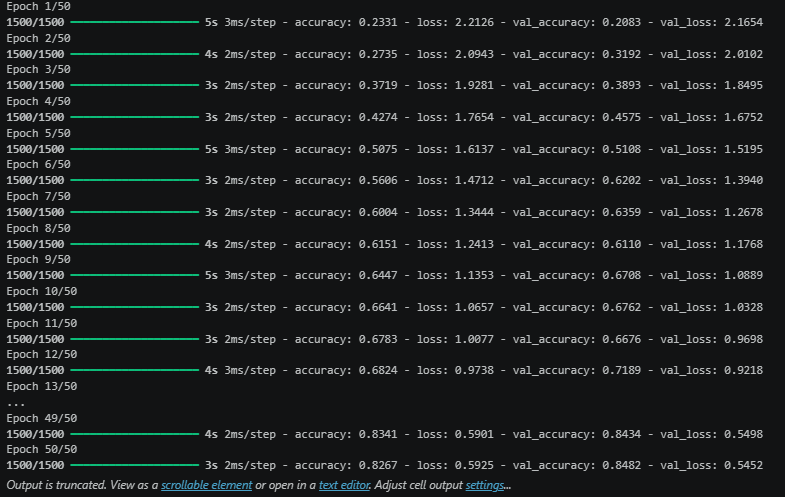

In [45]:
model.history.history

{'accuracy': [0.8104583621025085,
  0.8085416555404663,
  0.8070416450500488,
  0.8139583468437195,
  0.8224166631698608,
  0.8258541822433472,
  0.8210208415985107,
  0.8262083530426025,
  0.8188750147819519,
  0.8161666393280029,
  0.8381041884422302,
  0.8230000138282776,
  0.825166642665863,
  0.8328333497047424,
  0.840583324432373,
  0.8410416841506958,
  0.8293333053588867,
  0.8287291526794434,
  0.8471041917800903,
  0.8494166731834412,
  0.8528333306312561,
  0.8562708497047424,
  0.8504166603088379,
  0.8560000061988831,
  0.8636041879653931,
  0.8563125133514404,
  0.8461458086967468,
  0.8585000038146973,
  0.856124997138977,
  0.8621875047683716,
  0.867270827293396,
  0.8613125085830688,
  0.8577708601951599,
  0.8526458144187927,
  0.8660208582878113,
  0.8651458621025085,
  0.8667291402816772,
  0.86739581823349,
  0.8416666388511658,
  0.8616458177566528,
  0.8679583072662354,
  0.8609791398048401,
  0.8643958568572998,
  0.8689791560173035,
  0.8544583320617676,
  0.

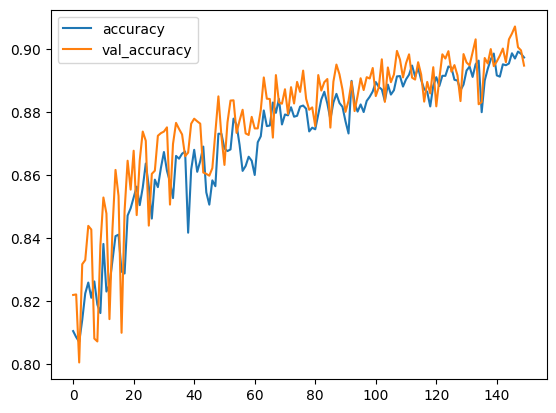

In [46]:
plt.plot(model.history.history['accuracy'],label = 'accuracy')
plt.plot(model.history.history['val_accuracy'],label = 'val_accuracy')
plt.legend()
plt.show()

In [47]:
model.evaluate(X_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8921 - loss: 0.3917


[0.39166688919067383, 0.8920999765396118]